# NB08 — Multiple Linear Regression

> **StatQuest: "Adding more variables means OLS needs to hold ALL other variables constant when estimating each coefficient."**

---

## The main ideas are:

1. Simple regression: one predictor, one slope
2. Multiple regression: many predictors, one slope PER predictor
3. Each slope means "effect of x_j, holding everything else constant"
4. The matrix normal equations generalise perfectly: b = (XtX)^-1 Xty
5. R^2 always increases with more variables — use Adjusted R^2 instead


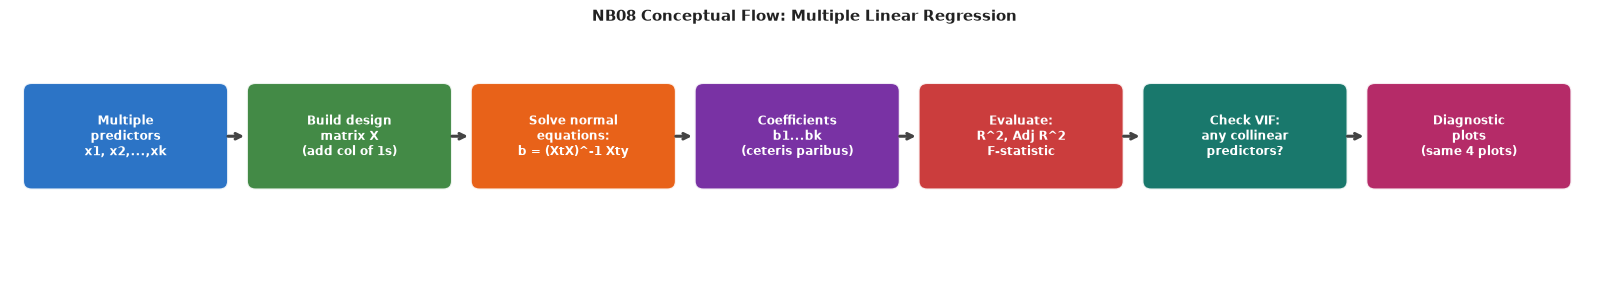

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

def flow_diagram(steps, title, colors=None, notes=None, figsize=(14, 2.8)):
    n = len(steps)
    default_colors = ['#1565C0','#2E7D32','#E65100','#6A1B9A',
                      '#00695C','#AD1457','#37474F','#4E342E',
                      '#0277BD','#558B2F','#C62828','#F57F17']
    colors = (colors or default_colors)[:n]
    notes  = notes or ['']*n
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-0.3, n*3.1); ax.set_ylim(-1.2, 2.4); ax.axis('off')
    bw, bh = 2.6, 1.3
    for i,(step,color,note) in enumerate(zip(steps,colors,notes)):
        x = i*3.1
        box = FancyBboxPatch((x,0.2),bw,bh,boxstyle="round,pad=0.12",
                             facecolor=color,edgecolor='white',linewidth=1.5,alpha=0.90)
        ax.add_patch(box)
        ax.text(x+bw/2,0.2+bh/2,step,ha='center',va='center',fontsize=8.5,
                color='white',fontweight='bold',multialignment='center')
        if note:
            ax.text(x+bw/2,0.02,note,ha='center',va='top',fontsize=7,
                    color='#555',style='italic')
        if i < n-1:
            ax.annotate('',xy=(x+bw+0.38,0.2+bh/2),xytext=(x+bw+0.08,0.2+bh/2),
                       arrowprops=dict(arrowstyle='->',color='#444',lw=2.2))
    ax.set_title(title,fontsize=11,fontweight='bold',pad=6,color='#222')
    plt.tight_layout(pad=0.4); plt.show()

flow_diagram(
    steps=[
        'Multiple\npredictors\nx1, x2,...,xk',
        'Build design\nmatrix X\n(add col of 1s)',
        'Solve normal\nequations:\nb = (XtX)^-1 Xty',
        'Coefficients\nb1...bk\n(ceteris paribus)',
        'Evaluate:\nR^2, Adj R^2\nF-statistic',
        'Check VIF:\nany collinear\npredictors?',
        'Diagnostic\nplots\n(same 4 plots)',
    ],
    title='NB08 Conceptual Flow: Multiple Linear Regression',
    colors=['#1565C0','#2E7D32','#E65100','#6A1B9A','#C62828','#00695C','#AD1457'],
    figsize=(16, 2.8),
)


## The "ceteris paribus" interpretation

**This is the single most important concept in multiple regression.**

When you have:
```
y = b0 + b1*x1 + b2*x2 + e
```

b1 means: *"Expected change in y for a 1-unit increase in x1, holding x2 CONSTANT."*

This is called **ceteris paribus** (Latin: all else equal).

**StatQuest example:** if y = salary, x1 = experience, x2 = education:
- b1 = 3000 means: one more year of experience -> $3000 more salary, *assuming same education level*
- This is DIFFERENT from the slope of experience in a simple regression (which ignores education)


In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

housing  = fetch_california_housing()
X_df     = pd.DataFrame(housing.data, columns=housing.feature_names)
y        = housing.target   # median house value ($100k)

print("Dataset: California Housing")
print(f"  n = {len(y)} census blocks")
print(f"  k = {X_df.shape[1]} predictors")
print(f"  y = median house value (in $100k)")
print()
print(X_df.describe().round(2))


Dataset: California Housing
  n = 20640 census blocks
  k = 8 predictors
  y = median house value (in $100k)

         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  
count  20640.00   20640.00  
mean      35.63    -119.57  
std        2.14       2.00  
min       32.54    -124.35  
25%       33.93    -121.80  
50%       34.26    -118.49  
75%       37.71    -118.01  
max      

In [3]:
import numpy as np
import statsmodels.api as sm
import pandas as pd
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X_arr   = housing.data
y       = housing.target
names   = housing.feature_names

Xsm  = sm.add_constant(X_arr)
res  = sm.OLS(y, Xsm).fit()
print(res.summary(xname=['const']+list(names)))

print("\n--- How to read this table ---")
print("coef     : slope for that predictor (holding all others constant)")
print("std err  : uncertainty (SE) of that coefficient")
print("t        : coef / std_err  (signal-to-noise ratio)")
print("P>|t|    : p-value  (< 0.05 = statistically significant)")
print("[0.025 0.975]: 95% confidence interval for the coefficient")


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     3970.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:53:06   Log-Likelihood:                -22624.
No. Observations:               20640   AIC:                         4.527e+04
Df Residuals:                   20631   BIC:                         4.534e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -36.9419      0.659    -56.067      0.0

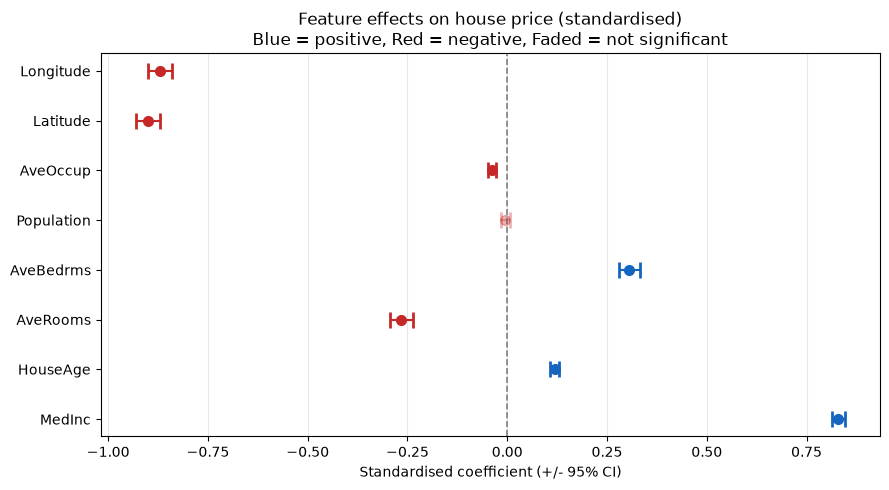

Standardised coefficients let you compare effect SIZES across predictors
(each predictor is on the same scale: 1 SD change)


In [4]:
# Coefficient plot — shows which predictors matter and their direction
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

scaler  = StandardScaler()
X_std   = scaler.fit_transform(X_arr)
Xsm_std = sm.add_constant(X_std)
res_std = sm.OLS(y, Xsm_std).fit()

coefs    = res_std.params[1:]    # skip intercept
ci_lo    = res_std.conf_int()[1:, 0]
ci_hi    = res_std.conf_int()[1:, 1]
pvals    = res_std.pvalues[1:]
sig      = pvals < 0.05

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#1565C0' if c > 0 else '#C62828' for c in coefs]
alpha  = [1.0 if s else 0.35 for s in sig]
for i, (c, lo, hi, color, a) in enumerate(zip(coefs, ci_lo, ci_hi, colors, alpha)):
    ax.errorbar(c, i, xerr=[[c-lo],[hi-c]], fmt='o', color=color,
                capsize=6, capthick=2, markersize=7, alpha=a)
ax.axvline(0, color='gray', linewidth=1.2, linestyle='--')
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.set_xlabel('Standardised coefficient (+/- 95% CI)')
ax.set_title('Feature effects on house price (standardised)\n'
             'Blue = positive, Red = negative, Faded = not significant')
ax.grid(alpha=0.3, axis='x'); plt.tight_layout(); plt.show()
print("Standardised coefficients let you compare effect SIZES across predictors")
print("(each predictor is on the same scale: 1 SD change)")


In [5]:
# F-statistic: does the WHOLE model explain something?
import statsmodels.api as sm
import numpy as np

# Full model vs intercept-only model
Xsm  = sm.add_constant(X_arr)
full = sm.OLS(y, Xsm).fit()

print("F-statistic:", round(full.fvalue, 2))
print("F p-value:  ", round(full.f_pvalue, 10))
print()
print("H0 for F-test: ALL slopes are zero simultaneously")
print("If F p-value < 0.05: at least ONE predictor is useful")
print()
print("Compare: individual t-tests vs F-test")
print("  t-test: 'is THIS specific predictor useful?'")
print("  F-test: 'is the WHOLE MODEL better than just the mean?'")


F-statistic: 3970.36
F p-value:   0.0

H0 for F-test: ALL slopes are zero simultaneously
If F p-value < 0.05: at least ONE predictor is useful

Compare: individual t-tests vs F-test
  t-test: 'is THIS specific predictor useful?'
  F-test: 'is the WHOLE MODEL better than just the mean?'


## Key Takeaways

| Concept | One-liner |
|---------|-----------|
| Multiple regression | y = b0 + b1*x1 + ... + bk*xk |
| Ceteris paribus | Each b_j is "effect of x_j, holding others constant" |
| Design matrix X | Rows = observations, Columns = [1, x1, x2,...,xk] |
| F-statistic | Does the whole model explain more than nothing? |
| Adjusted R^2 | R^2 penalised for adding useless predictors |

**Next: NB09 — what happens when x1 and x2 are correlated (multicollinearity).**
